**AdaBoost**

对之前欠拟合的训练实例给予更多的 attention

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=1000, noise=0.22, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [2]:
single_stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,        # 弱分类器数量 T
    learning_rate=1.0,      # 学习率，缩放 α_t 权重
    random_state=42
)

single_stump.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [5]:
def print_acc(model, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    print(f"{name:20s} | Train Acc:{train_acc:.4f} | Test Acc:{test_acc:.4f}")

print_acc(single_stump, "Single Decision Stump")
print_acc(ada_clf, "AdaBoost")

# 查看每一轮弱分类器权重 α_t
print("\n每个弱分类器权重 α_t：")
print(np.round(ada_clf.estimator_weights_, 4))

Single Decision Stump | Train Acc:0.8171 | Test Acc:0.8233
AdaBoost             | Train Acc:0.9743 | Test Acc:0.9700

每个弱分类器权重 α_t：
[1.4971 0.855  1.3649 0.6776 1.0841 0.6525 0.7049 0.7318 0.7844 0.7833
 0.3146 0.6988 0.4841 0.5278 0.7079 0.6003 0.5133 0.5008 0.5218 0.4177
 0.3612 0.3525 0.4529 0.5518 0.3344 0.5909 0.3333 0.534  0.4117 0.3234
 0.162  0.2431 0.3669 0.283  0.4199 0.2548 0.2556 0.2547 0.3601 0.411
 0.4308 0.2553 0.1335 0.1251 0.3134 0.3781 0.2379 0.4011 0.0853 0.1245]


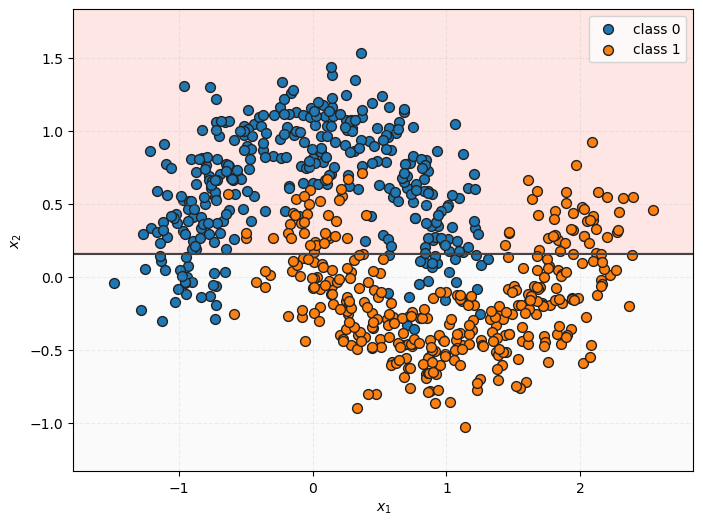

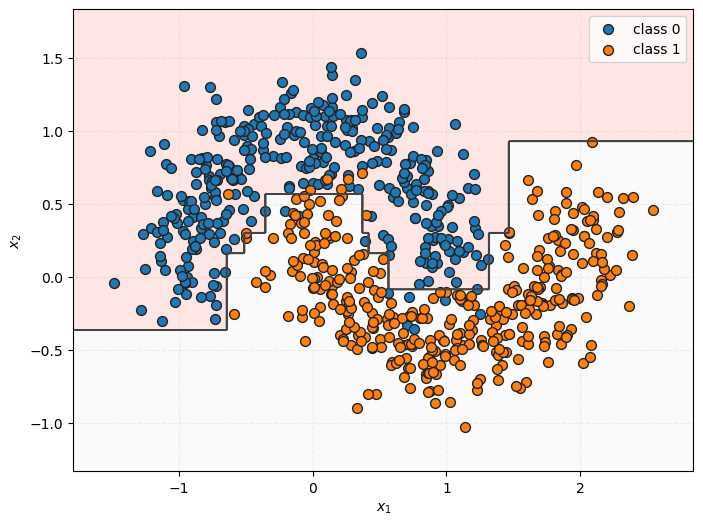

In [6]:
def plot_decision_boundary(clf, X, y, title=None):
    plt.figure(figsize=(8,6))
    x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
    x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500),
                           np.linspace(x1_min, x1_max, 500))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = clf.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 画出样本
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask,0], X[mask,1], s=50, edgecolors="#222222", label=f"class {label}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

# 依次画出单个模型 + 投票集成
plot_decision_boundary(single_stump, X_train, y_train)
plot_decision_boundary(ada_clf, X_train, y_train)

**梯度提升**

常用于解决回归问题

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.linspace(-2, 2, 300).reshape(-1, 1)
y = np.sin(3 * X).ravel() + np.random.normal(0, 0.15, size=X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
gbr = GradientBoostingRegressor(
    n_iter_no_change=100,  # 弱学习器（决策树）数量
    max_depth=2,           # 单棵树最大深度，控制复杂度
    learning_rate=0.1,     # 学习率 η，缩放每棵树贡献
    loss="squared_error",  # 平方损失，回归标准选择
    random_state=42
)
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [16]:
y_train_pred = gbr.predict(X_train)
y_test_pred = gbr.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"训练集 MSE: {train_mse:.4f}")
print(f"测试集 MSE: {test_mse:.4f}")

训练集 MSE: 0.0140
测试集 MSE: 0.0291


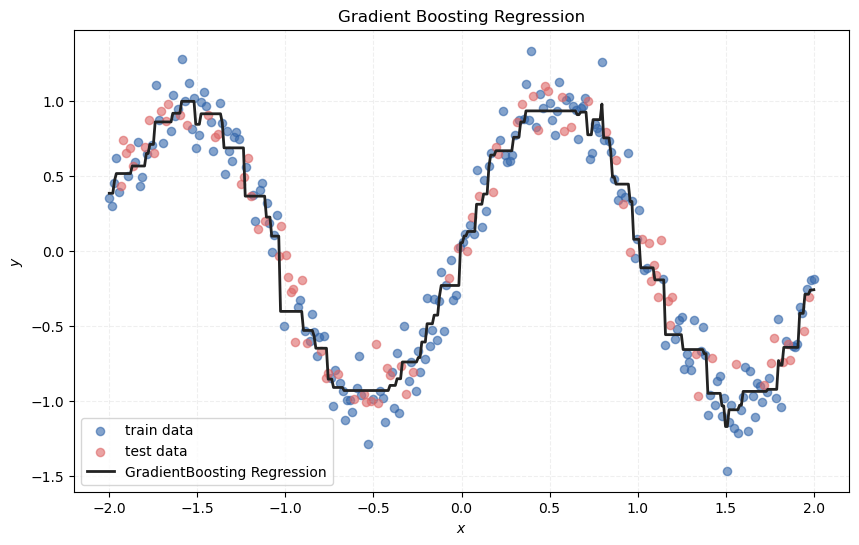

In [15]:
plt.figure(figsize=(10,6))
# 原始散点
plt.scatter(X_train, y_train, c="#3366aa", s=35, alpha=0.6, label="train data")
plt.scatter(X_test, y_test, c="#dd6666", s=35, alpha=0.6, label="test data")

# 连续预测曲线
X_range = np.linspace(-2, 2, 400).reshape(-1,1)
y_range_pred = gbr.predict(X_range)
plt.plot(X_range, y_range_pred, color="#222222", lw=2, label="GradientBoosting Regression")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.grid(alpha=0.2, linestyle="--")
plt.show()

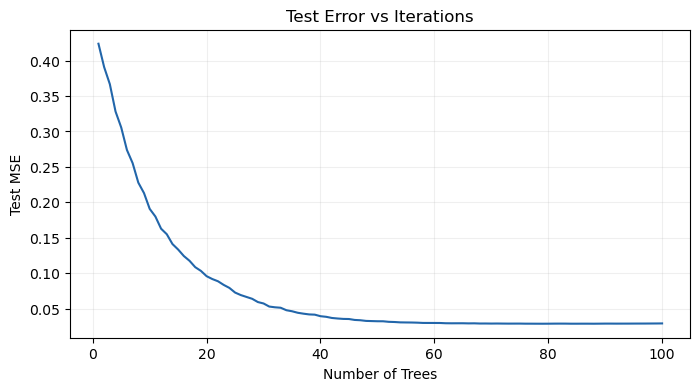

In [17]:
test_error = []
estimator_range = range(1, gbr.n_estimators + 1)

for n in estimator_range:
    # 使用前n棵树做预测
    y_pred_n = gbr.staged_predict(X_test)
for n, pred in enumerate(gbr.staged_predict(X_test), start=1):
    mse = mean_squared_error(y_test, pred)
    test_error.append(mse)

plt.figure(figsize=(8,4))
plt.plot(estimator_range, test_error, color="#2266aa")
plt.xlabel("Number of Trees")
plt.ylabel("Test MSE")
plt.title("Test Error vs Iterations")
plt.grid(alpha=0.2)
plt.show()